In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

from pathlib import Path
import sys

MAL_DIR = Path.cwd()
if MAL_DIR.name != "MAL":
    MAL_DIR = next(path for path in [Path.cwd(), *Path.cwd().parents] if path.name == "MAL")

sys.path.insert(0, str(MAL_DIR))
from scripts.preprocessing import AutomatedPreprocessor

# Here we import and split the data
# df = pd.read_csv("../../data/processed/linearized_session_windows_30min.csv")
df = pd.read_csv("../../data/processed/sessions_scored_30min.csv")

TARGET_COLUMN = "focus_score"
columns_to_ignore = [TARGET_COLUMN]

feature_columns = [
    column for column in df.columns
    if column not in columns_to_ignore and pd.api.types.is_numeric_dtype(df[column])
]

X = df[feature_columns].copy()
y = df[TARGET_COLUMN].copy()

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

# Usage from scripts/
preprocessor = AutomatedPreprocessor()
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [8]:
# Logistic Regression

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

param_grid = {
    "C": [0.01, 0.1, 1, 5, 10, 50, 100],
    "class_weight": ["balanced"],
}

log_reg = LogisticRegression(
    max_iter=5000,
    solver="saga",
    n_jobs=-1,
    random_state=42,
    tol=1e-3,
    warm_start=False,
    penalty="l2",
    verbose=0,
    fit_intercept=True,
    
)

grid_search = GridSearchCV(
    log_reg,
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)
grid_search.fit(X_train_processed, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV f1_macro: {grid_search.best_score_:.4f}")

c:\Users\piotr\Desktop\University\Semester4\SEP4\SEP4\.venv-1\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\piotr\Desktop\University\Semester4\SEP4\SEP4\.venv-1\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Best Parameters: {'C': 0.01, 'class_weight': 'balanced'}
Best CV f1_macro: 0.1948


c:\Users\piotr\Desktop\University\Semester4\SEP4\SEP4\.venv-1\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\piotr\Desktop\University\Semester4\SEP4\SEP4\.venv-1\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



--- Train Metrics ---
Accuracy:  0.2019
Precision (weighted): 0.2328
Recall (weighted):    0.2019
F1 Score (weighted):  0.1929

--- Test/Validation Metrics ---
Accuracy:  0.1963
Precision (weighted): 0.2286
Recall (weighted):    0.1963
F1 Score (weighted):  0.1876

--- Model Coefficients (Top 20 by Absolute Value) ---
temperature_mean_temperature_max_temperature_min_temperature_latest                            0.113400
humidity_std_humidity_range                                                                    0.065962
light_min                                                                                      0.049846
light_std_light_range                                                                          0.039929
session_duration_minutes_humidity_count_temperature_count_noise_count_co2_count_light_count   -0.019775
temperature_std_temperature_range                                                             -0.018256
noise_min_noise_latest_noise_mean_noise_max            

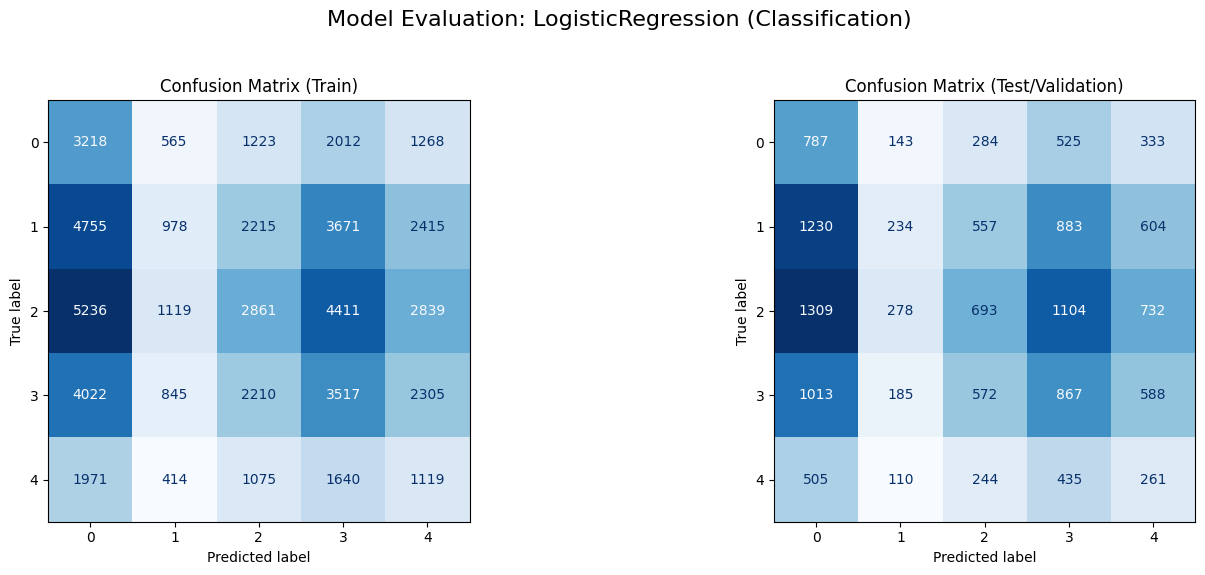

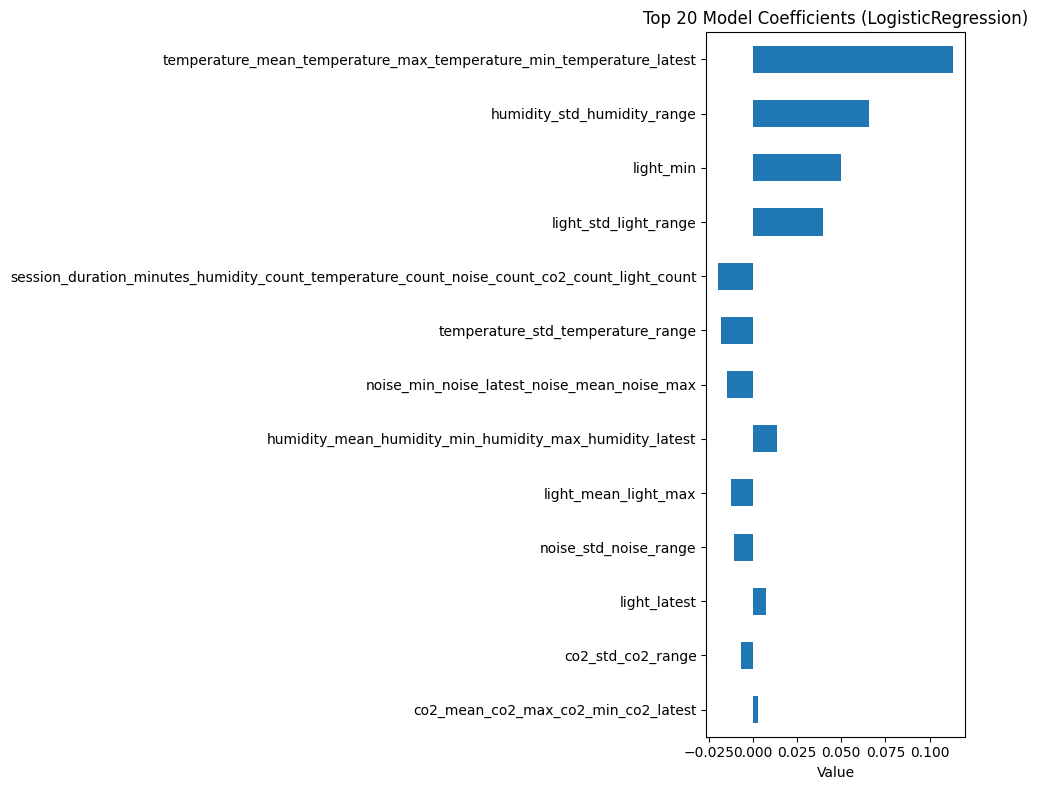

In [9]:
import importlib
import scripts.evaluation_metrics
importlib.reload(scripts.evaluation_metrics)
from scripts.evaluation_metrics import evaluate_model

best_model.fit(X_train_processed, y_train)

evaluate_model(best_model, X_train_processed, X_val_processed, y_train, y_val, True);

## Conclusion

Logistic Regression is a simple, interpretable baseline for the focus score prediction task.

Using the same preprocessing and split as the Random Forest notebook makes the comparison fair, but the linear model typically underperforms on this dataset.

Even so, it remains useful for explainability and as a quick sanity check before testing more complex models.
